In [1]:
import numpy as np
import matplotlib.pyplot as plt
from GWFish.modules.fft import fft_lal_timeseries
from GWFish import detection
from scipy.interpolate import interp1d
from scipy.integrate import simpson
import math
import lal
from lal import REAL8TimeSeries, CreateREAL8TimeSeries, REAL8Vector, CreateREAL8Vector

ModuleNotFoundError: No module named 'lal'

In [ ]:
filename = "23_gwstrain_trim.dat"

In [ ]:
def make_fft_from_time_series(time_series_input, df, dt, title="Ines_Ludo"):
    '''
    Returns the FFT done through the lal library given a time series. Also returns the frequency range.
    time_series_input: array of the time series 
    df: frequency step
    dt: time step
    title: title of the time series (optional)
    '''
    dims = len(time_series_input)
    time_series = CreateREAL8Vector(dims)
    time_series.data = time_series_input
    ts = CreateREAL8TimeSeries(title, 1, 0, dt, lal.DimensionlessUnit, dims)
    ts.data = time_series
    fft_dat = fft_lal_timeseries(ts, df).data.data
    freq_range = np.linspace( 0, df * len(fft_dat), len(fft_dat) )
    return fft_dat, freq_range

def frequency_plot_options(ax, fig, y_bounds = [1e-25, 1e-22], x_bounds = [1, 1e4]):
    ax.set_yscale("log")
    ax.set_ylabel(f"$|\\tilde{{h}}_{{+/x}}|$")
    ax.set_xlabel("f[Hz]")
    ax.set_xscale("log")
    ax.set_ylim(y_bounds)
    ax.set_xlim(x_bounds)
    ax.grid()
    ax.legend()
    fig.tight_layout()
    return 0

/tmp/ipykernel_10775/1249564473.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


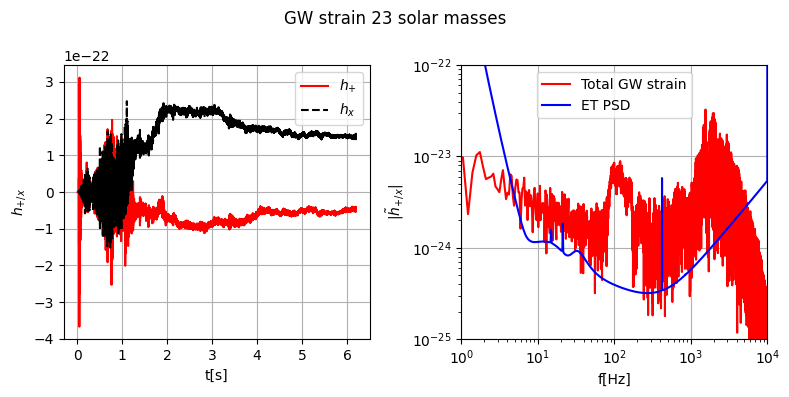

In [ ]:
distance = 10 #kpc
kpc = 3.086e21 #cm
dims = 300_000

GW_dat = np.loadtxt(filename).T

fft_h_plus = np.fft.fft(GW_dat[1], dims, norm="forward" ) / (distance * kpc)
fft_h_cross = np.fft.fft(GW_dat[2], dims, norm="forward" ) / (distance * kpc)
frequencies = np.fft.fftfreq(dims, d=np.mean(np.diff(GW_dat[0])))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

fig.suptitle("GW strain 23 solar masses")

ax1.plot(GW_dat[0], GW_dat[1]/(distance * kpc), "r", label="$h_{{+}}$")
ax1.plot(GW_dat[0], GW_dat[2]/(distance * kpc), "--k", label="$h_{{x}}$")
ax1.legend()
ax1.set_ylabel(f"$h_{{+/x}}$")
ax1.set_xlabel("t[s]")
ax1.grid()

halfies = dims//2

detector = detection.Detector("ET")
psd = detector.components[0].Sn(frequencies[:halfies])

h_total = np.abs(np.sqrt(fft_h_plus**2 + fft_h_cross**2))

ax2.plot(frequencies[:halfies], 2*np.sqrt(frequencies[:halfies])*h_total[:halfies], "r", label="Total GW strain")
ax2.plot(frequencies[:halfies], np.sqrt(psd[:halfies]), "b", label="ET PSD")
frequency_plot_options(ax2, fig)
fig.show()

In [ ]:
a = 2*h_total[:halfies]*np.sqrt(frequencies[:halfies])
b = np.sqrt(psd[:halfies])
above_cond = a > b
a_int = a[above_cond]
b_int = b[above_cond]
f_int = frequencies[:halfies][above_cond]
simpson( a_int/b_int, np.log(f_int) ), (a_int/b_int).sum()/4000

(36.071906448614286, 34.27372416477834)

/tmp/ipykernel_10775/856556085.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


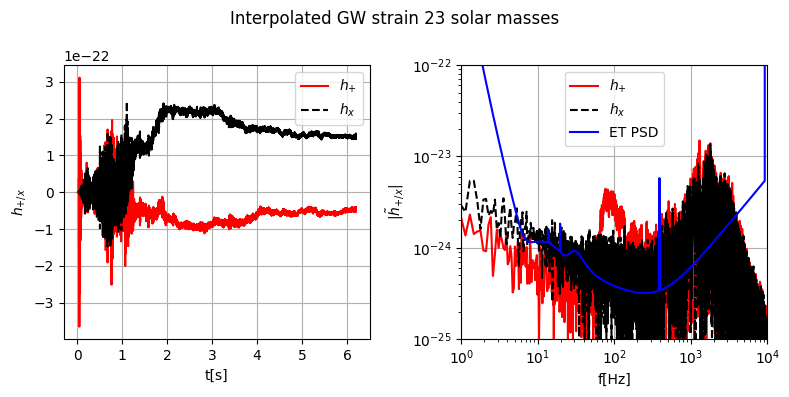

In [ ]:
# Interpolate data so that bins are equally spaced
new_time = np.linspace(min(GW_dat[0]), max(GW_dat[0]), dims)
interpolated_data = interp1d(GW_dat[0], GW_dat[1:], axis=1)(new_time)
GW_dat_interp = interpolated_data / (distance * kpc)

fft_h_plus = np.fft.fft(GW_dat_interp[0], dims, norm="forward" ) 
fft_h_cross = np.fft.fft(GW_dat_interp[1], dims, norm="forward" )
frequencies = np.fft.fftfreq(dims, d=np.mean(np.diff(new_time)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

fig.suptitle("Interpolated GW strain 23 solar masses")

ax1.plot(new_time, GW_dat_interp[0], "r", label="$h_{{+}}$")
ax1.plot(new_time, GW_dat_interp[1], "--k", label="$h_{{x}}$")
ax1.legend()
ax1.set_ylabel(f"$h_{{+/x}}$")
ax1.set_xlabel("t[s]")
ax1.grid()
halfies = dims//2

ax2.plot(frequencies[:halfies], np.sqrt(frequencies[:halfies])*np.abs(fft_h_plus)[:halfies], "r", label="$h_{{+}}$")
ax2.plot(frequencies[:halfies], np.sqrt(frequencies[:halfies])*np.abs(fft_h_cross)[:halfies], "--k", label="$h_{{x}}$")
ax2.plot(frequencies[:halfies], np.sqrt(psd), "b", label="ET PSD")
frequency_plot_options(ax2, fig)
fig.show()

/tmp/ipykernel_10775/2575125160.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


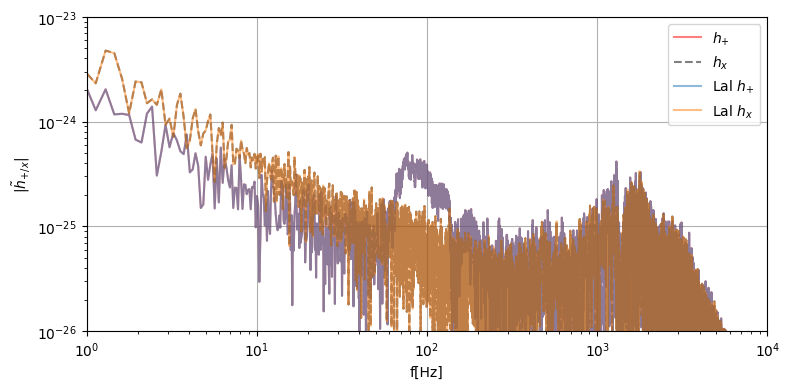

In [ ]:
df = frequencies[1] - frequencies[0]
dt = new_time[1] - new_time[0]

fft_dat_plus, freq_range = make_fft_from_time_series(GW_dat_interp[0], df, dt)
fft_dat_cross, _ = make_fft_from_time_series(GW_dat_interp[1], df, dt)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

ax.plot(frequencies, abs(fft_h_plus), "r", label="$h_{{+}}$", alpha=0.5)
ax.plot(frequencies, abs(fft_h_cross), "--k", label="$h_{{x}}$", alpha=0.5)
ax.plot(freq_range, abs(fft_dat_plus)/max(new_time), label="Lal $h_{{+}}$", alpha=0.5)
ax.plot(freq_range, abs(fft_dat_cross)/max(new_time), label="Lal $h_{{x}}$", alpha=0.5)
frequency_plot_options(ax, fig, y_bounds=[1e-26, 1e-23])
fig.show()

In [ ]:
time_dim = dims//2+1

normalization_factor = 1#max(new_time) #Important to normalize the time series

time = GW_dat[0]
min_time = min(time)
max_time = max(time)
new_time = np.linspace(min_time, max_time, dims)

interpolated_data = interp1d(time, GW_dat[1:], axis=1)(new_time)
GW_dat_interp = np.vstack(interpolated_data) / (distance * kpc)

units = lal.DimensionlessUnit
dt = (new_time[2] - new_time[1])
time_series_p = CreateREAL8Vector(dims)
time_series_p.data = GW_dat_interp[0]
ts_p = CreateREAL8TimeSeries("Ines_Ludo_p", 0, 0, dt, units, dims)
ts_p.data = time_series_p
fft_dat_plus = abs(fft_lal_timeseries(ts_p, df).data.data)

time_series_c = CreateREAL8Vector(dims)
time_series_c.data = GW_dat_interp[1]
ts_c = CreateREAL8TimeSeries("Ines_Ludo_c", 0, 0, dt, units, dims)
ts_c.data = time_series_c
fft_dat_cross = abs(fft_lal_timeseries(ts_c, df).data.data) 

geo_time = 1395964818
timevector = np.ones( time_dim ) * geo_time

ConfigDet = 'detectors.yaml'
detector = detection.Detector("ET", config=ConfigDet)

phi_in = np.exp(1.j*(2*detector.frequencyvector*np.pi*geo_time)).T[0] #TODO shape is (dims, 1) makes it too high dimensional
fft_dat_plus = phi_in*np.conjugate( fft_lal_timeseries(ts_p, 1).data.data )
fft_dat_cross = phi_in*np.conjugate( fft_lal_timeseries(ts_c, 1).data.data )

# GW Fish format for hfp and hfc
hfp = fft_dat_plus[:, np.newaxis]
hfc = fft_dat_cross[:, np.newaxis]
polarizations = np.hstack((hfp, hfc)) / normalization_factor

detectors = ["ET"]
#network = detection.Network(detector_ids = detectors, detection_SNR=(0, 0))

#change to dataframe
params = {
    "ra" : math.radians(200.405),
    "dec" : math.radians(-12.008),
    "psi" : np.pi*0.3,
    "max_frequency_cutoff" : 2048
}

args = (params, detector, polarizations, timevector)

signal = detection.projection(*args)
frequencyvector = detector.frequencyvector

frequencyvector = freq_range

component_SNRs = detection.SNR(detector, signal, frequencyvector=np.squeeze(frequencyvector))
print(component_SNRs)
out_SNR = np.sqrt(np.sum(component_SNRs**2))
print(out_SNR)

# timevector = np.ones * geocent_time 1980 GPS in seconds
# Gaussian ra dec
# Psi 0, 2pi flat 
# 0, 2pi flat phase

[50.58911705 43.91728395 58.00229117]
88.61293570518475


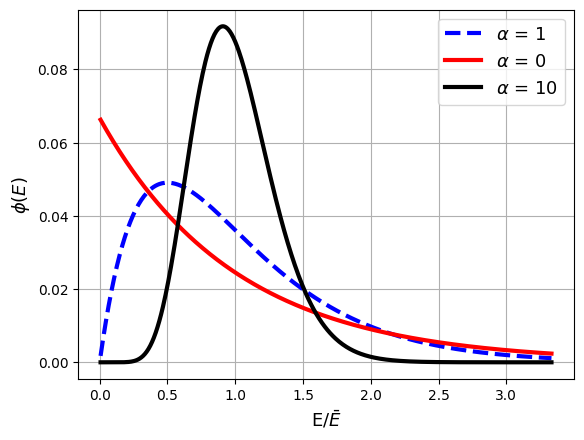

8.737330023419892e+57


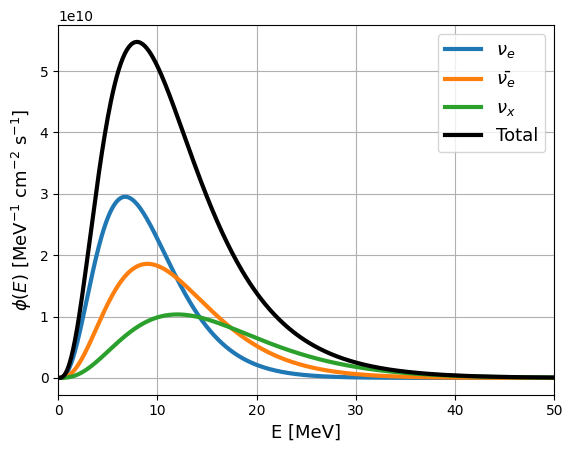

In [2]:
import scipy

def flux_pinched(E, E_med, alpha):

    norm = 1/E_med * (alpha+1)**(alpha+1)/(scipy.special.gamma(alpha+1)) 

    x = (E/E_med)
    func = (x) ** (alpha) * np.exp( - (alpha+1) * (x) )

    return norm * func

E = np.linspace( 0.1, 50, 500 )

plt.plot(E/15, flux_pinched(E, 15, 1), "--b", label="$\\alpha$ = 1", linewidth=3)
plt.plot(E/15, flux_pinched(E, 15, 0), "r", label="$\\alpha$ = 0", linewidth=3)
plt.plot(E/15, flux_pinched(E, 15, 10), "k", label="$\\alpha$ = 10", linewidth=3)
plt.legend(fontsize=13)
plt.ylabel("$\\phi(E)$", fontsize=13)
plt.xlabel("E/$\\bar{{E}}$", fontsize=13)
plt.grid()
plt.show()

kpc = 3.086e21 #cm
erg = 624151 #MeV

labels = [f"$\\nu_{{e}}$", f"$\\bar{{\\nu_{{e}}}}$", f"$\\nu_{{x}}$"]
e_med = [9, 12, 16]
alphas = [3, 3, 3]
luminosities = [73.9, 73.5, 27.8*2]
factors = np.array( [73.9/13, 73.5/15.4, 27.8*2/15.7] ) / (4 * np.pi * (10*kpc)**2) * 1e51 * erg

summed = 0

for k, l in enumerate( labels ):
    spec = factors[k] * flux_pinched(E, e_med[k], alphas[k])
    summed += spec
    plt.plot(E, spec, label=l, linewidth=3)

plt.plot(E, summed, "k", label="Total", linewidth=3)
plt.legend(fontsize=13)
plt.ylabel("$\\phi(E)$ [MeV$^{-1}$ cm$^{-2}$ s$^{-1}$]", fontsize=13)
plt.xlabel("E [MeV]", fontsize=13)
plt.xlim(0, 50)
plt.grid()
plt.show()

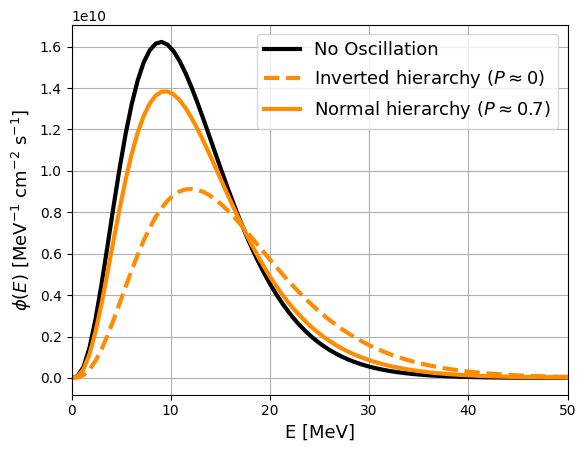

In [ ]:
def neutrino_temp(t, tau_1 = 0.1, tau_2 = 1):
    #Best fit data
    return (1-np.exp(-t/tau_1)) * np.exp(-t/tau_2)

total_E = 3e53 * erg # in MeV
E_meds = np.array([9, 12, 16]) # in MeV

def differential_spec(E, total_E, avg_E, D = 10 * kpc):
    #Essentially just a pinched dirac just rewrite it 
    pre = (total_E/6) / (4 * np.pi * D**2) 
    alpha = 3
    T = avg_E / (1 + alpha)
    gamma_alpha = 24
    dist = E ** alpha * np.exp( -E/T ) / (T ** (alpha + 2) * gamma_alpha)

    return pre * dist 

E_range = np.linspace(0, 60, 100)
specs = differential_spec(E_range[:,None], total_E, E_meds)

p = 0
ih_hierachy = specs.T[1] * p + specs.T[2] * (1-p)
eff = 1
threshold = 1 # MeV

#plt.plot(E_range, specs)
plt.plot(E_range, specs.T[1], "k", label="No Oscillation", linewidth=3)
plt.plot(E_range, ih_hierachy, "--", color="darkorange", label="Inverted hierarchy ($P\\approx 0$)", linewidth=3)
p = 0.7
nh_hierachy = specs.T[1] * p + specs.T[2] * (1-p)
plt.plot(E_range, nh_hierachy, color="darkorange", label="Normal hierarchy ($P\\approx 0.7$)", linewidth=3)
plt.legend(fontsize=13)
plt.ylabel("$\\phi(E)$ [MeV$^{-1}$ cm$^{-2}$ s$^{-1}$]", fontsize=13)
plt.xlabel("E [MeV]", fontsize=13)
plt.xlim(0, 50)
plt.grid()
plt.show()


In [ ]:
from scipy.integrate import simpson

def IBD_precise(E_nu):
  '''
  Implements the approximation (25) Phys. Lett., B564:42–54, 2003 Vissani
  '''
  E_th = 1.806
  A = 10**(-43) #cm^2
  delta = 1.293
  m_pos = 0.511
  E_pos = E_nu - (delta)
  E_pos[E_nu < E_th] = m_pos
  p_pos = (E_pos**2-m_pos**2)**0.5
  f_E = E_nu**( - 0.07056 + 0.02018 * np.log(E_nu) - 0.001953 * np.log(E_nu)**3 )
  return A * E_pos * p_pos * f_E

cross_section = IBD_precise(E_range)

M_h2o = 18.01528 #g/mol
Na = 6.022e23 #mol^-1
water_mass = 230592898 #g ie 230 tons
N_h2o = water_mass / M_h2o * Na # 18 is the molar mass of water
N_p = 2 * N_h2o

IBD_interactions = N_p * cross_section * ih_hierachy * eff
IBD_interactions[E_range <= 3] = 0

print(simpson(IBD_interactions, E_range))

56.29298073386686


/tmp/ipykernel_10775/894672010.py:14: RuntimeWarning: divide by zero encountered in log
  f_E = E_nu**( - 0.07056 + 0.02018 * np.log(E_nu) - 0.001953 * np.log(E_nu)**3 )
/tmp/ipykernel_10775/894672010.py:14: RuntimeWarning: invalid value encountered in subtract
  f_E = E_nu**( - 0.07056 + 0.02018 * np.log(E_nu) - 0.001953 * np.log(E_nu)**3 )


In [ ]:
print("evts/ton", simpson(IBD_interactions, E_range) /water_mass * 1e6) 

evts/ton 0.24412278618340993


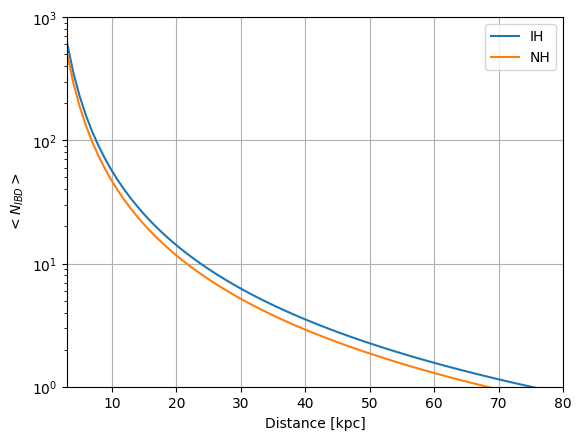

In [ ]:
distance_factor = ( 10/np.linspace(3, 100, 100) ) ** 2 #in Kpc
all_ints = simpson(IBD_interactions, E_range)
IBD_interactions_vs_distance = all_ints * distance_factor

IBD_interactions_nh = N_p * cross_section * nh_hierachy * eff
IBD_interactions_nh[E_range <= 3] = 0
all_ints_nh = simpson(IBD_interactions_nh, E_range)
IBD_interactions_vs_distance_nh = all_ints_nh * distance_factor

distances = np.linspace(3, 100, 100)
plt.plot(distances, IBD_interactions_vs_distance, label="IH")
plt.plot(distances, IBD_interactions_vs_distance_nh, label="NH")
plt.yscale("log")
plt.ylabel(f"$<N_{{IBD}}>$")
plt.xlabel("Distance [kpc]")
plt.grid()
plt.legend()
plt.ylim(1, 1e3)
plt.xlim(3, 80)
plt.show()

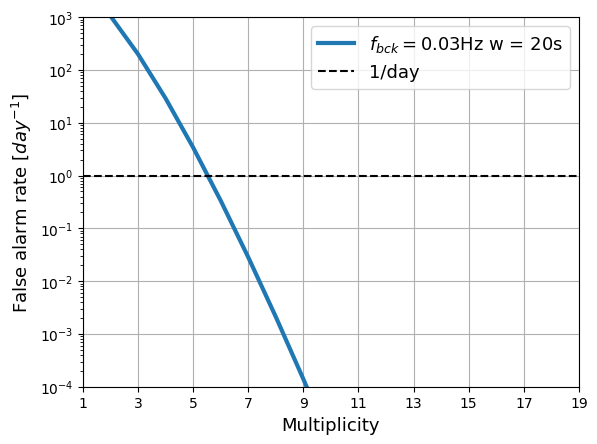

In [ ]:
def poisson_distribution(n, k):
    pois = np.exp(-n) * n**k / math.factorial(k)
    return pois

def f_im(m_i, f_bck_, w = 20):
    N = int( 60 * 60 * 24 / w * 2 ) # factor 2 to account for overlap
    n = f_bck_ * w
    k_range = np.arange(m_i, int( 100 ) ) # no need to sum to infinity
    day_rate = np.array([poisson_distribution(n, k) for k in k_range])
    day_rate = np.nansum( day_rate )
    return N * ( day_rate)

def time_distribution(t, N_tot, t1 = 0.01, t2 = 1):
    return N_tot * (1 - np.exp(-t/t1)) * np.exp(-t/t2)

f_bck = 0.03 #Hz
w = 20

m_i = np.arange(1, 20)
f_ims = np.array( [f_im(ms, f_bck, w) for ms in m_i] ) #per second

plt.plot(m_i, f_ims, linewidth=3, label=f"$f_{{bck}} = ${f_bck}Hz w = 20s") #f_im < 1/day
plt.yscale("log")
plt.ylabel("False alarm rate [$day^{{-1}}$]", fontsize=13)
plt.xlabel("Multiplicity", fontsize=13)
plt.xticks(np.arange(1, 20, 2))
plt.xlim(1, 19)
plt.ylim(1e-4, 1e3)
plt.hlines(1, 1, 20, color="k", linestyle="--", label="1/day")
plt.grid()
plt.legend(fontsize=13)
plt.show()

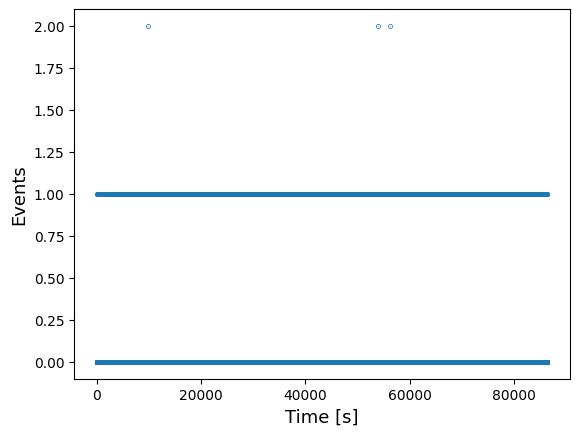

In [ ]:
sec_frac = 10 #100 ms
N_gens = 60 * 60 * 24 * sec_frac #generate 30 days of data
evs_per_bins = f_bck / sec_frac  #mHz
generated_bins = np.random.poisson( evs_per_bins, N_gens )
times = np.arange(0, N_gens )/sec_frac

plt.scatter(times, generated_bins, linewidth=3, s = 0.3)
plt.ylabel("Events", fontsize=13)
plt.xlabel("Time [s]", fontsize=13)  
plt.show()

In [ ]:
window_samples = sec_frac * w
out_bins = generated_bins.reshape((-1, window_samples))
multiplicity = out_bins.sum(axis=1)
condition = (multiplicity > 1)
multiplicity_cond = multiplicity[condition]
times_cond = out_bins[condition]
dt = abs( np.argmax(times_cond, axis=1) - np.argmin(times_cond, axis=1) ) / sec_frac
print((dt)[(dt)<20].shape)
epsilon = multiplicity_cond / dt

(518,)


In [ ]:
out_bins.shape, window_samples, times_cond.shape, np.argmax(times_cond, axis=1).shape, sec_frac

((4320, 200), 200, (518, 200), (518,), 10)

0.6


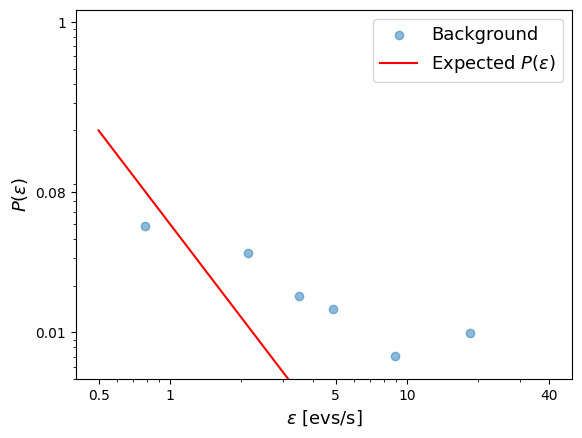

In [ ]:
counts, edges = np.histogram(epsilon, bins = int( len(epsilon)**0.5 ), density=True)

print(f_bck * w)

epsilons = np.linspace(0.5, 40, 100)
pdf = 1/epsilons**2 / 20 #* (f_bck*w)

edges_in = edges[:-1] - (edges[1] - edges[0])/2
plt.scatter( edges_in, counts, alpha=0.5, label="Background" )
plt.plot(epsilons, pdf, "r", label="Expected $P(\\epsilon)$")
plt.yscale("log")
plt.xscale("log")
plt.ylim(0.005, 1.2)
plt.yticks( [0.01, 0.08, 1], labels=["0.01", "0.08", "1"] )
plt.xticks( [0.5, 1, 5, 10, 40], labels=["0.5", "1", "5", "10", "40"] )
plt.ylabel("$P(\\epsilon)$", fontsize=13)
plt.xlabel("$\\epsilon$ [evs/s]", fontsize=13)
plt.legend(fontsize=13)
plt.show()

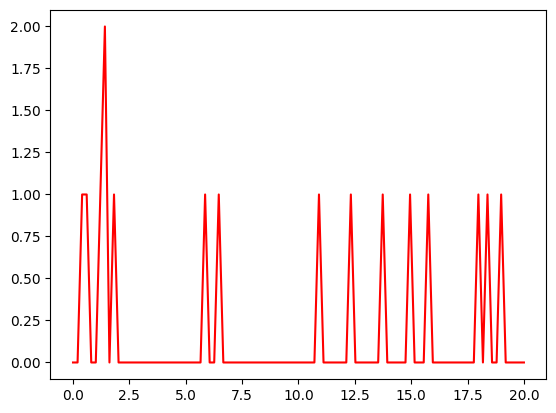

In [ ]:
times = np.linspace(0, 20, 100)
bck = np.random.poisson(f_bck * w/5, len(times) )
y = time_distribution(times, 1)
sig = np.random.poisson(time_distribution(times, 1), len(times) )

plt.plot(times, sig+bck, "r", label="$t_1 = 0.01, t_2 = 1$")
plt.show()

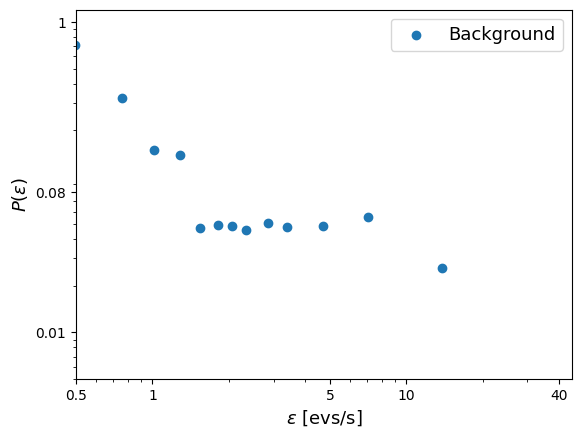

In [ ]:
f_bck = 0.012 #Hz
w = 20
evs = w * f_bck
days = 200

sec_frac = 7 #100 ms
N_gens = days * 60 * 60 * 24 * sec_frac #generate N days of data
evs_per_bins = f_bck / sec_frac  #mHz
generated_bins = np.random.poisson( evs_per_bins, N_gens )

window_samples = sec_frac * w
out_bins = generated_bins.reshape((-1, window_samples))
multiplicity = out_bins.sum(axis=1)
condition = (multiplicity > 1)
multiplicity_cond = multiplicity[condition]
times_cond = out_bins[condition]
last = window_samples-np.argmax(np.flip(times_cond, axis=1)>0, axis=1)
first = np.argmax(times_cond>0, axis=1)
dt = (last-first)/sec_frac
dt_cond = dt > 0
epsilon = multiplicity_cond[dt_cond] / dt[dt_cond]

counts, edges = np.histogram(epsilon, bins = int( len(epsilon)**0.4 ), density=True)

edges_in = edges[:-1] + (edges[1] - edges[0])/2
plt.scatter( edges_in, counts, label="Background"  )
plt.yscale("log")
plt.xscale("log")
plt.ylim(0.005, 1.2)
plt.xlim(0.5, 45)
plt.yticks( [0.01, 0.08, 1], labels=["0.01", "0.08", "1"] )
plt.xticks( [0.5, 1, 5, 10, 40], labels=["0.5", "1", "5", "10", "40"] )
plt.ylabel("$P(\\epsilon)$", fontsize=13)
plt.xlabel("$\\epsilon$ [evs/s]", fontsize=13)
plt.legend(fontsize=13)
plt.show()

In [ ]:
int( len(epsilon)**0.5 )

145

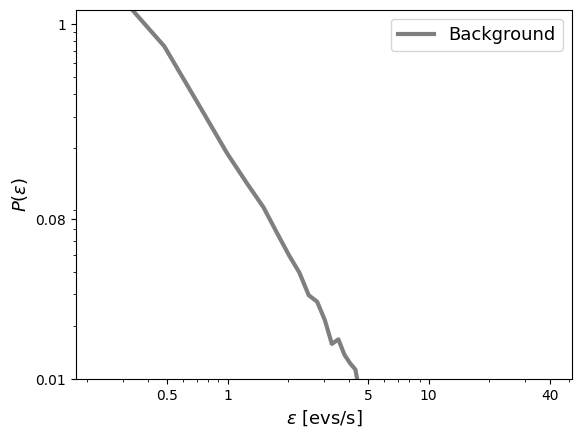

In [ ]:
f_bck = 0.012 #Hz
w = 20

days = 1000
#sec_frac = 10 #100 ms
#N_gens = int ( days * 60 * 60 * 24 / w )  #* sec_frac #generate 30 days of data
N_windows = 1_000_000
evs_per_window =  f_bck * w 
multiplicity = np.random.poisson( evs_per_window, N_windows ) 
multiplicity = multiplicity[multiplicity > 1] #only 2 or more events
d1 = np.random.uniform(0, w, len(multiplicity))
d2 = np.random.uniform(0, w, len(multiplicity))
dts = abs(d2 - d1) #differences 
epsilon = multiplicity/dts 

counts, edges = np.histogram(epsilon, range=(0.1, 40), bins = int( len(epsilon)**0.5 ), density=True)

edges_in = edges[:-1] + (edges[1] - edges[0])/2
plt.plot( edges_in, counts, "k", alpha=0.5, label="Background", linewidth=3 )
plt.yscale("log")
plt.xscale("log")
plt.ylim(0.01, 1.2)
plt.yticks( [0.01, 0.08, 1], labels=["0.01", "0.08", "1"] )
plt.xticks( [0.5, 1, 5, 10, 40], labels=["0.5", "1", "5", "10", "40"] )
plt.ylabel("$P(\\epsilon)$", fontsize=13)
plt.xlabel("$\\epsilon$ [evs/s]", fontsize=13)
plt.legend(fontsize=13)
plt.show()

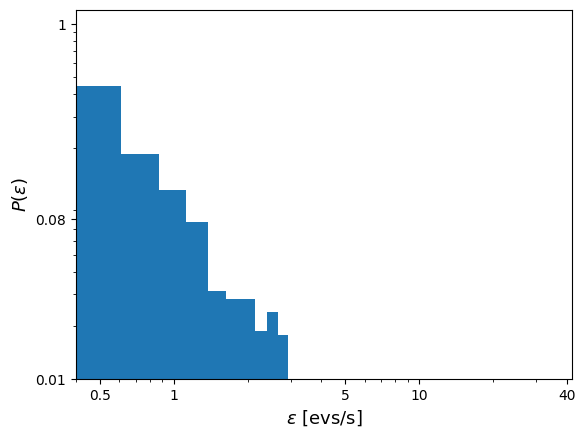

In [ ]:
plt.hist(epsilon/12.818, range=(0.1, 40), bins=int( len(epsilon)**0.5 ), density="True")
plt.yscale("log")
plt.xscale("log")
plt.ylim(0.01, 1.2)
plt.xlim(0.4, 42)
plt.yticks( [0.01, 0.08, 1], labels=["0.01", "0.08", "1"] )
plt.xticks( [0.5, 1, 5, 10, 40], labels=["0.5", "1", "5", "10", "40"] )
plt.ylabel("$P(\\epsilon)$", fontsize=13)
plt.xlabel("$\\epsilon$ [evs/s]", fontsize=13)
plt.show()

1.0112778819387358 4.267116027571834


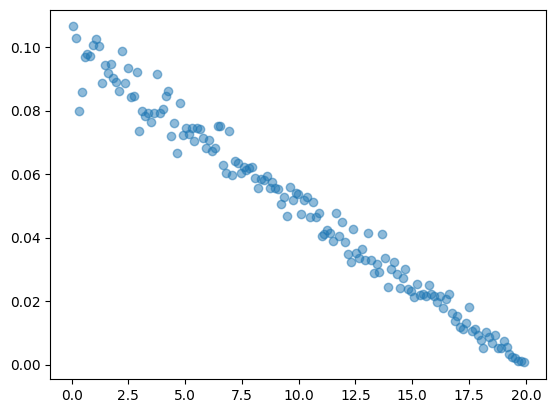

In [ ]:
counts, edges = np.histogram(dts, density=True, bins=int(len(dts)**0.5))#, range=(0.1, 40), bins = int( len(epsilon)**0.5 ), density=True)

edges_in = edges[:-1] + (edges[1] - edges[0])/2

print( np.mean(multiplicity) * simpson(counts/edges_in, edges_in ), np.mean(epsilon))

plt.scatter( edges_in, counts, alpha=0.5, label="Background" )
plt.show()


In [ ]:
evs_per_window

0.24

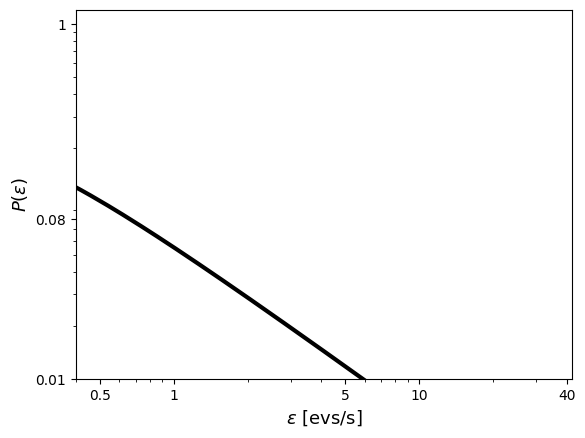

In [ ]:
from scipy.stats import poisson
from scipy.integrate import quad


rv = poisson(f_bck * w)
def integral_epsilon(eps, dt, w = 20):
    return  rv.pmf( eps * dt ) * dt * (2/w) * ( 1 - dt/w )

def integral_epsilon_n( n, dt, w=20 ):
    return rv.pmf(n) * dt * (2/w) * ( 1 - dt/w )

epsilon_in = np.linspace(0.1, 40, 1000)
dts = np.linspace(0, 20, 100)
p_eps = []
for epsi in epsilon_in:
    max_int = int(epsi * 20)
    integral_range = np.arange( max_int + 1 ) 
    p_eps.append( sum( integral_epsilon_n( integral_range, integral_range/epsi ) ) )

p_eps = np.array(p_eps)
plt.plot(epsilon_in, p_eps, "k", label="Background", linewidth=3)

plt.yscale("log")
plt.xscale("log")
plt.ylim(0.01, 1.2)
plt.xlim(0.4, 42)
plt.yticks( [0.01, 0.08, 1], labels=["0.01", "0.08", "1"] )
plt.xticks( [0.5, 1, 5, 10, 40], labels=["0.5", "1", "5", "10", "40"] )
plt.ylabel("$P(\\epsilon)$", fontsize=13)
plt.xlabel("$\\epsilon$ [evs/s]", fontsize=13)

plt.show()